<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
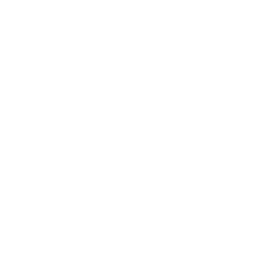
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Campaign Performance Analysis</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Media & Advertising &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

This notebook builds a synthetic portfolio of 200 digital advertising campaigns and asks a single planning question: **which channels and creative formats actually deliver return on ad spend (ROAS)**, and how much of the variation in ROAS can a model attribute to those levers?

> **Key finding (from the executed output below):** Email is the standout channel, averaging a ROAS of **9.21** versus **3.3 to 3.9** for display, search, social, and video. It also posts the highest mean click-through rate (**0.0372**) and by far the lowest cost per acquisition (**$5.39**). On the creative side, **video** leads with a mean ROAS of **7.28** and the highest CTR (**0.0328**). A general linear model finds that **channel and creative type are both statistically significant drivers of ROAS** (channel F = 9.32, p < .0001; creative type F = 2.77, p = 0.0433); campaign week and the channel-by-creative interaction are not significant, and the model explains **47.1%** of ROAS variance (R-square = 0.471).

## Data Sources

All data in this notebook is **synthetic**, generated in the DATA step below with a fixed seed (`call streaminit(42)`) so the analysis is fully reproducible. No external feeds are used. The DATA step emits **200 campaigns**.

| Field | Description |
|-------|-------------|
| `campaign_id` | Campaign identifier (1-200) |
| `channel` | Media channel: search, social, display, email, video |
| `creative_type` | Creative format: static, video, carousel, text |
| `budget` | Campaign budget in dollars |
| `impressions`, `clicks`, `conversions` | Funnel volumes |
| `revenue` | Revenue attributed to the campaign |
| `ctr`, `roas`, `cpa` | Click-through rate, return on ad spend, cost per acquisition |
| `week_num` | Campaign flight week (1-12) |

The generator bakes in two deliberate effects so the analysis has something to find: **email** campaigns get a CTR and conversion-rate lift, and **video** creatives get a smaller lift. Everything else is noise.

---

## 1. Data Preparation



In [1]:
/* --------------------------------------------------------
   Generate synthetic campaign performance data
   -------------------------------------------------------- */
data campaigns;
    call streaminit(42);
    do campaign_id = 1 to 200;
        channel = scan("search social display email video",
                       ceil(rand("Uniform") * 5));
        creative_type = scan("static video carousel text",
                            ceil(rand("Uniform") * 4));
        budget = round(500 + rand("Exponential") * 4500, 1);
        impressions = round(budget * (80 + rand("Normal", 0, 20)));
        clicks = round(impressions *
            (0.02 + 0.015 * (channel = "email") +
             0.01 * (creative_type = "video") +
             rand("Normal", 0, 0.005)));
        conversions = round(clicks *
            (0.04 + 0.03 * (channel = "email") +
             0.02 * (creative_type = "video") +
             rand("Normal", 0, 0.01)));
        revenue = round(conversions * (45 +
            rand("Normal", 0, 15)), 0.01);
        ctr = round(clicks / max(1, impressions), 0.0001);
        roas = round(revenue / max(1, budget), 0.01);
        cpa = round(budget / max(1, conversions), 0.01);
        week_num = ceil(rand("Uniform") * 12);
        output;
    end;
run;


NOTE: DATA campaigns


NOTE: Wrote campaigns (200 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


---

## 2. Descriptive Statistics



                                                  The MEANS Procedure

                                            Analysis Variable : impressions

        channel           N Obs            Mean          Median         Std Dev
        -----------------------------------------------------------------------
        display              47  321138.9148936  276864.0000000  255859.8111725
        email                42  380390.3333333  267766.5000000  304535.8704882
        search               44  486887.0227273  357903.0000000  440997.0518553
        social               40  398117.9500000  356374.5000000  281420.3861719
        video                27  411706.7777778  184688.0000000  411345.7799725
        -----------------------------------------------------------------------

                                               Analysis Variable : clicks

        channel           N Obs           Mean         Median        Std Dev
        ---------------------------------------------------

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_channel_creative_type.spec.json
NOTE: PROC FREQ statement used.


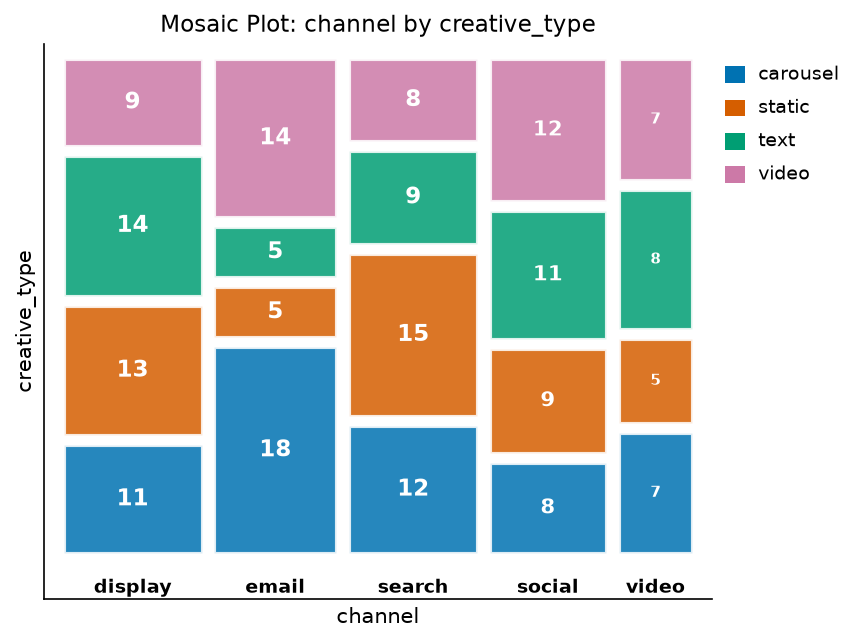

In [2]:
/* --------------------------------------------------------
   Campaign KPIs by channel and creative type
   -------------------------------------------------------- */
proc means data=campaigns n mean median std;
    class channel;
    var impressions clicks conversions ctr roas cpa;
run;

proc means data=campaigns n mean median;
    class creative_type;
    var ctr roas revenue;
run;

proc freq data=campaigns;
    tables channel * creative_type / nocol nopercent;
run;


---

## 3. Visualisation



NOTE: ODS Graphics is ON (width=800px, height=500px, format=SVG).
NOTE: PROC SGPLOT data=campaigns

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: PROC SGPLOT data=campaigns

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: PROC SGPLOT data=campaigns

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


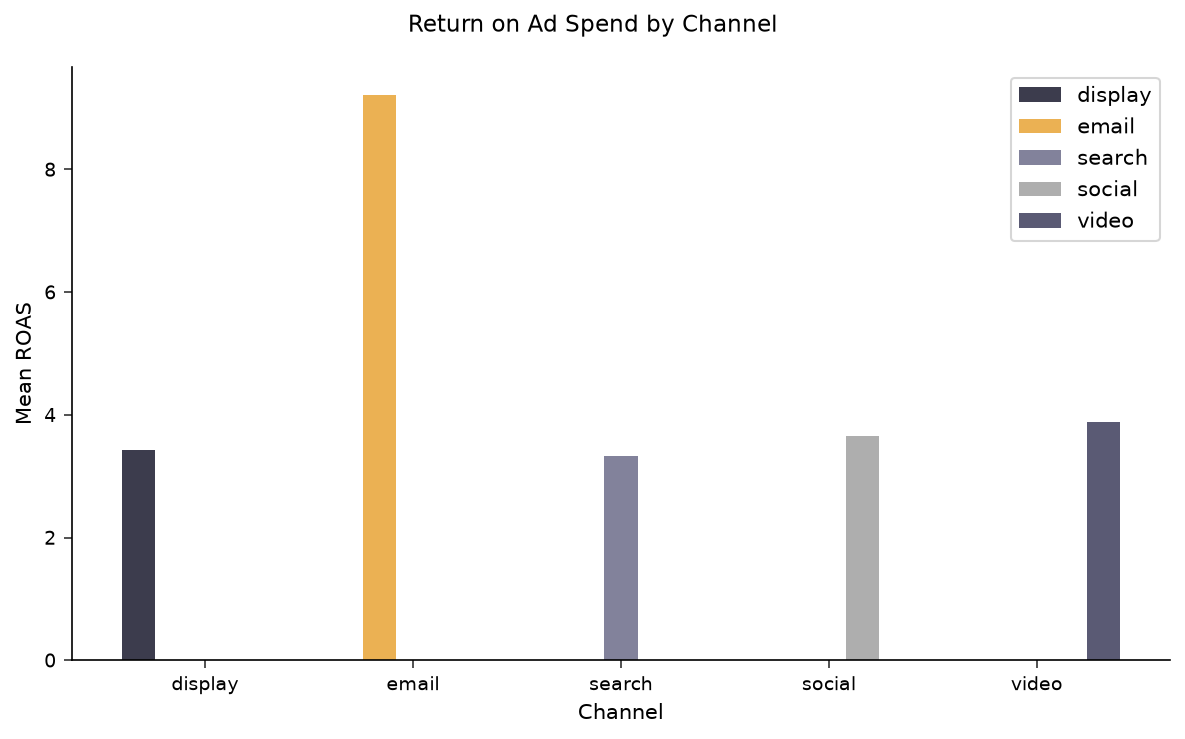

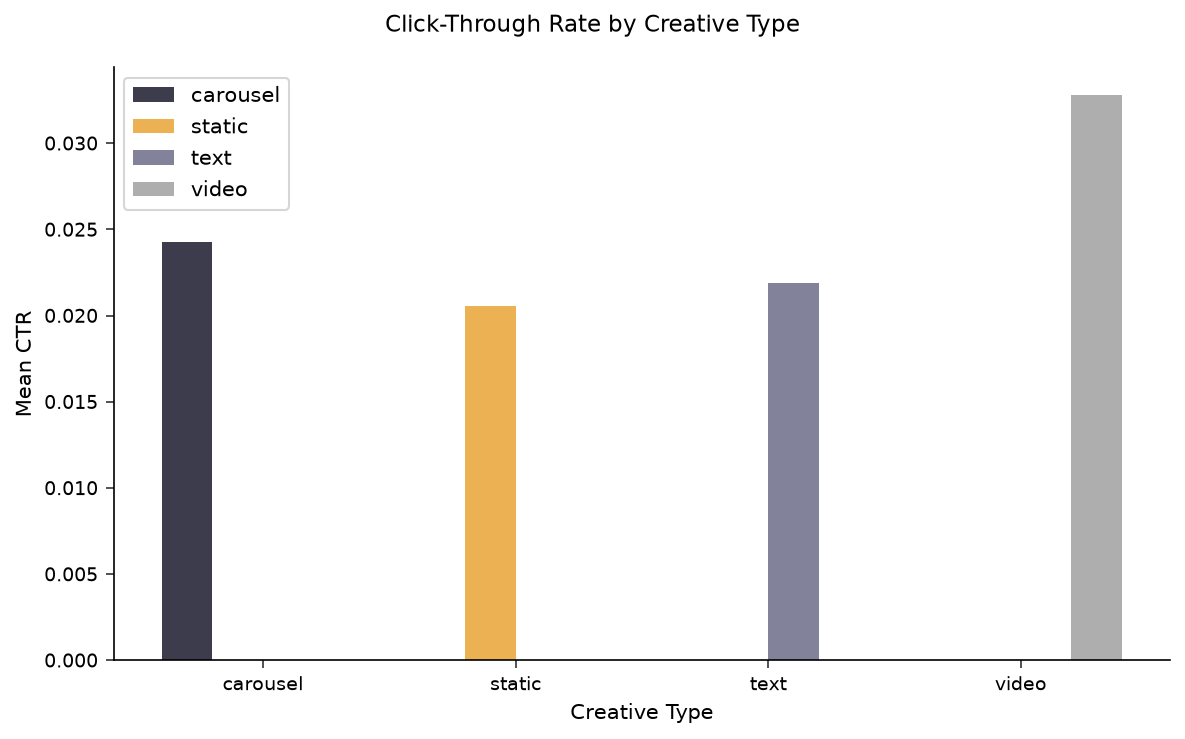

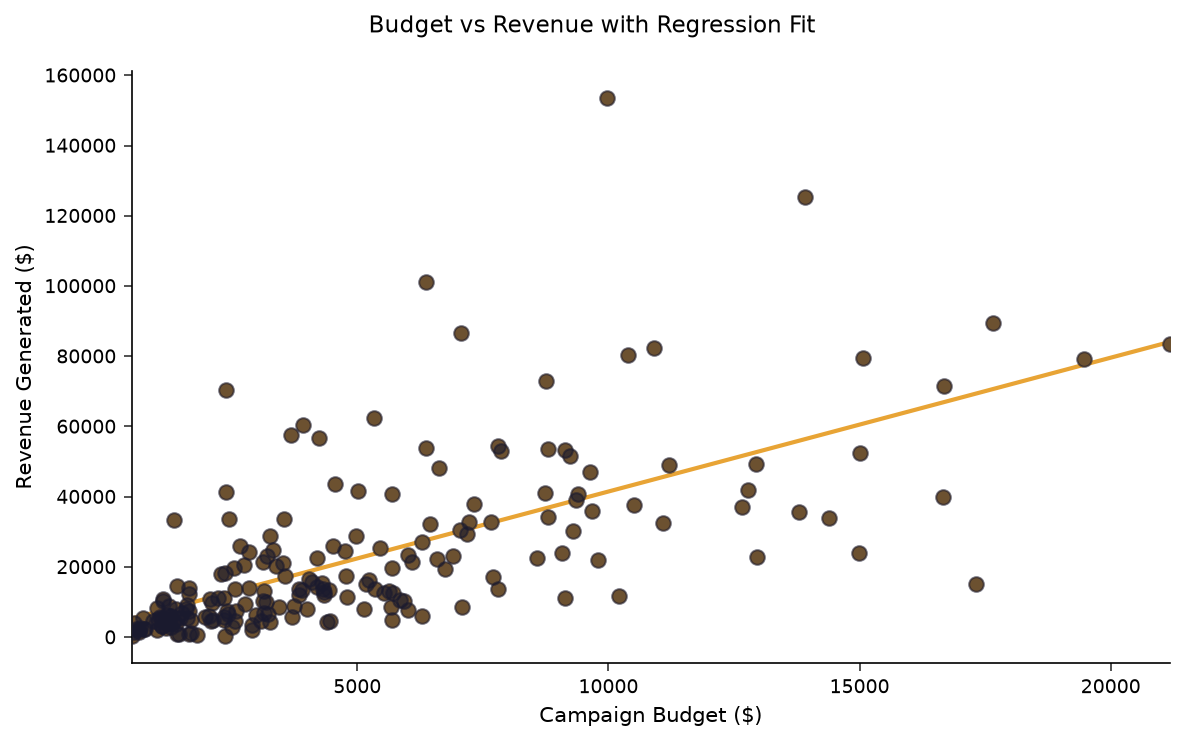

In [3]:
/* --------------------------------------------------------
   ROAS comparison by channel and creative
   McKinsey palette: navy #1a1a2e, gold #e8a435
   -------------------------------------------------------- */
ods graphics on / width=800px height=500px imagefmt=svg;

proc sgplot data=campaigns;
    styleattrs datacolors=(cx1A1A2E cxE8A435 cx6C6C8A cxA0A0A0 cx3D3D5C);
    vbar channel / response=roas stat=mean
        group=channel fillattrs=(transparency=0.15);
    xaxis label="Channel";
    yaxis label="Mean ROAS";
    title "Return on Ad Spend by Channel";
run;

proc sgplot data=campaigns;
    styleattrs datacolors=(cx1A1A2E cxE8A435 cx6C6C8A cxA0A0A0);
    vbar creative_type / response=ctr stat=mean
        group=creative_type fillattrs=(transparency=0.15);
    xaxis label="Creative Type";
    yaxis label="Mean CTR";
    title "Click-Through Rate by Creative Type";
run;

proc sgplot data=campaigns;
    scatter x=budget y=revenue /
        markerattrs=(symbol=circlefilled size=7 color=cx1A1A2E)
        transparency=0.4;
    reg x=budget y=revenue / lineattrs=(color=cxE8A435 thickness=2);
    xaxis label="Campaign Budget ($)";
    yaxis label="Revenue Generated ($)";
    title "Budget vs Revenue with Regression Fit";
run;


---

## 4. Statistical Analysis



                               The GLM Procedure                                
                            Dependent Variable: roas                            

Source                       DF  Sum of Squares  Mean Square   F Value    Pr > F
---------------------  --------  --------------  -----------  --------  --------
channel                       4       326.70787     81.67697      9.32    <.0001
creative_type                 3        72.75956     24.25319      2.77    0.0433
week_num                      1         0.09506      0.09506      0.01    0.9172
channel:creative_type        12        10.25394      0.85449      0.10    1.0000
Error                       179      1568.90144      8.76481                    

Root MSE           2.96054    R-Square            0.4706
Adj R-Sq            0.4114



NOTE: PROC GLM data=campaigns

NOTE: Warning message:
NOTE: In readLines(file("stdin")) : incomplete final line found on 'stdin'
NOTE: ODS plot written: glm_residuals_vs_predicted.spec.json
NOTE: ODS plot written: glm_residual_histogram_panel.spec.json
NOTE: ODS plot written: glm_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: glm_qq_plot.spec.json
NOTE: PROC GLM ODS Graphics generated.
NOTE: PROC GLM statement used.
NOTE: DATA _glm_done


NOTE: Wrote _glm_done (1 rows, 1 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


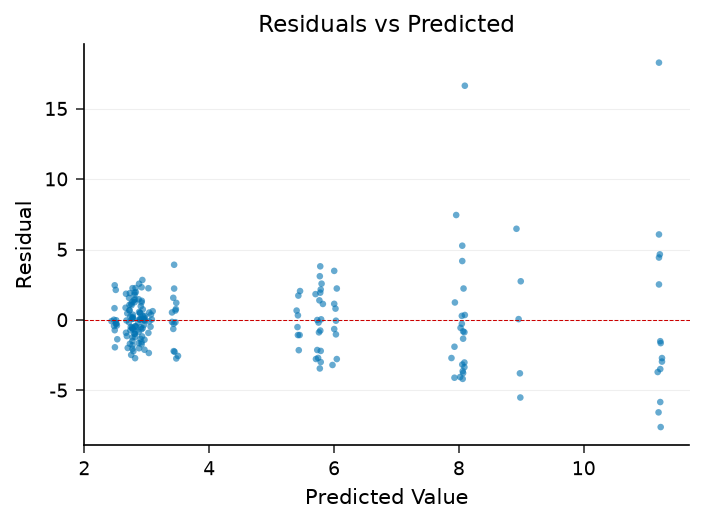

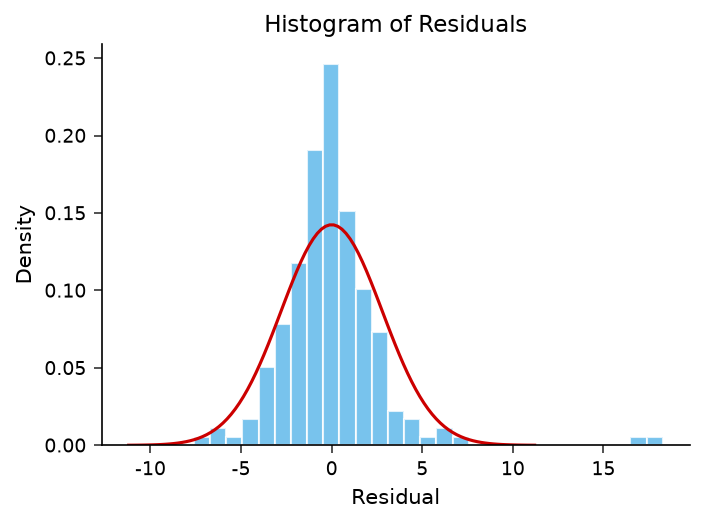

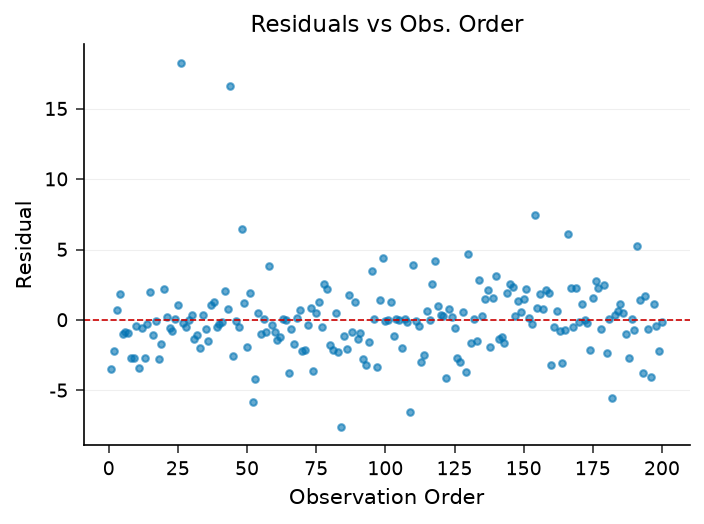

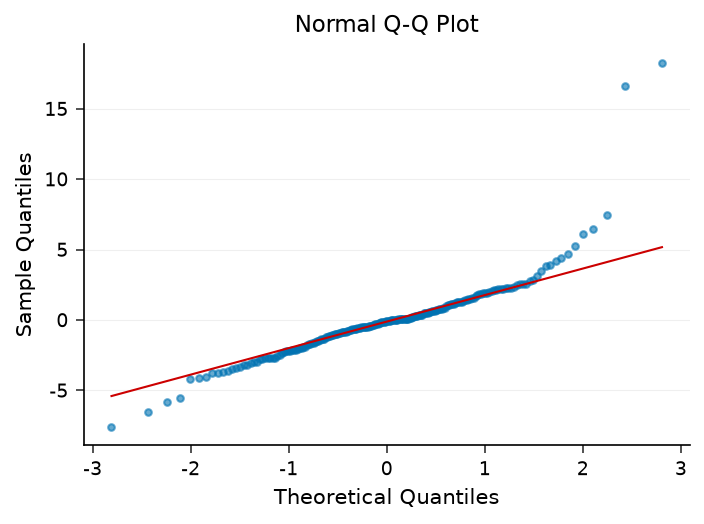

In [4]:
/* --------------------------------------------------------
   GLM: Model ROAS as function of channel, creative, timing
   -------------------------------------------------------- */
proc glm data=campaigns;
    class channel creative_type;
    model roas = channel creative_type week_num
        channel*creative_type / ss3;
run;


/* force the kernel to flush wrapper-proc output into this cell */
data _glm_done; synced = 1; run;


                                                   The REG Procedure                                                    
                                                     Model: MODEL1                                                      
                                              Dependent Variable: revenue                                               

Source                 DF      Sum of Squares        Mean Square   F Value    Pr > F
---------------  --------  ------------------  -----------------  --------  --------
Model                   4   99230490151.30289  24807622537.82572    309.67    <.0001
Error                 195   15621182615.96340     80108628.79981                    
Corrected Total       199  114851672767.26628                                       

Root MSE        8950.34238    R-Square            0.8640
Dependent Mean   22502.47955    Adj R-Sq            0.8612
Coeff Var         39.77492

                         Parameter Estimates                      

NOTE: PROC REG data=campaigns

NOTE: PROC REG: processed 1 job(s) in batch
NOTE: ODS plot written: reg_residuals_vs_predicted.spec.json
NOTE: ODS plot written: reg_residual_histogram_panel.spec.json
NOTE: ODS plot written: reg_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: reg_qq_plot.spec.json
NOTE: ODS plot written: reg_cooksd.spec.json
NOTE: PROC REG ODS Graphics generated.
NOTE: DATA _reg_done


NOTE: Wrote _reg_done (1 rows, 1 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


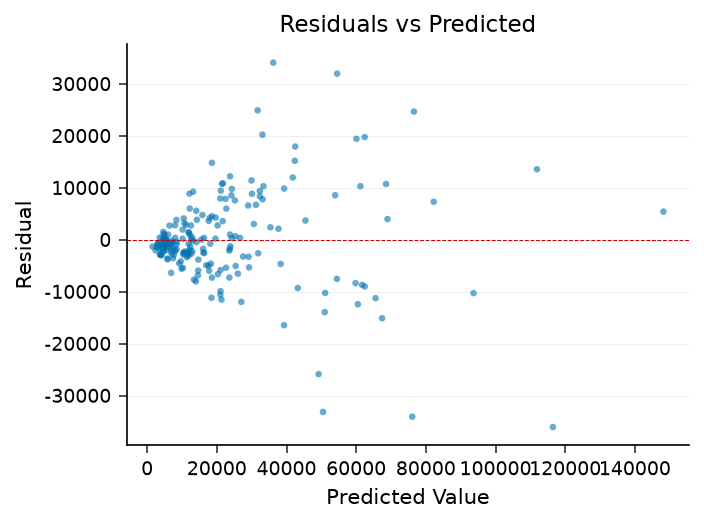

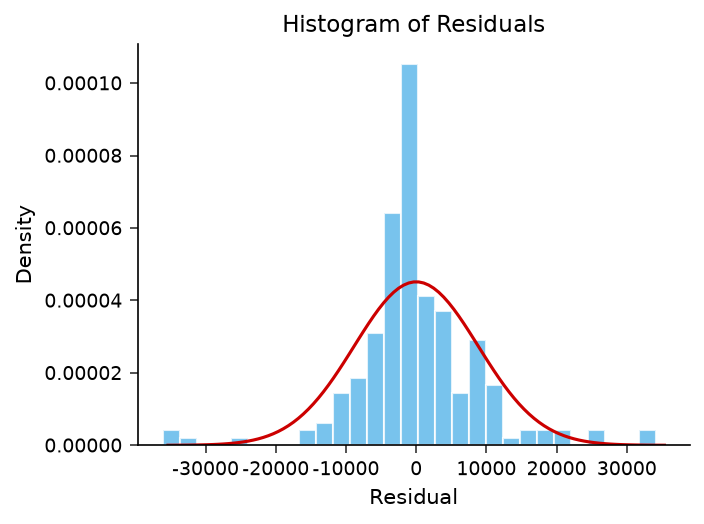

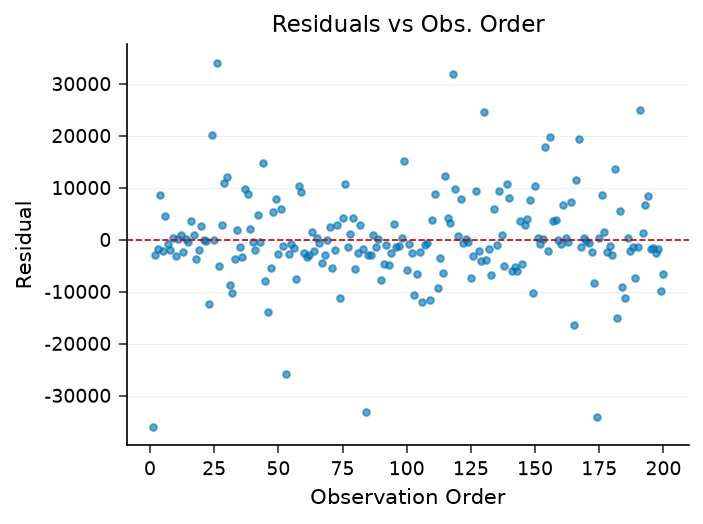

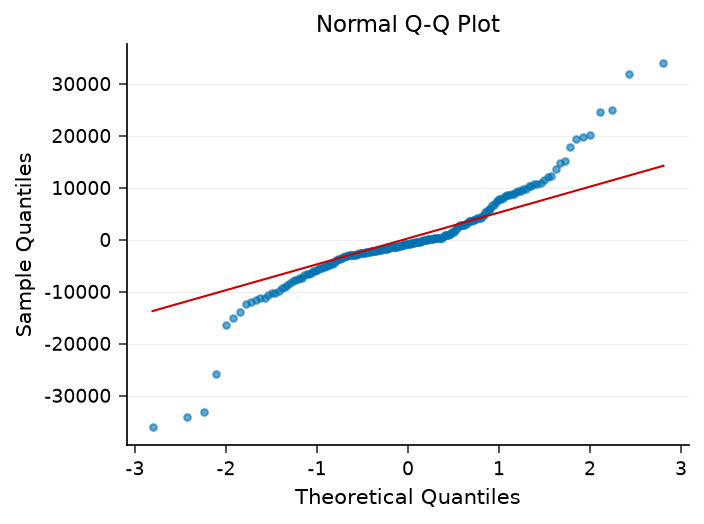

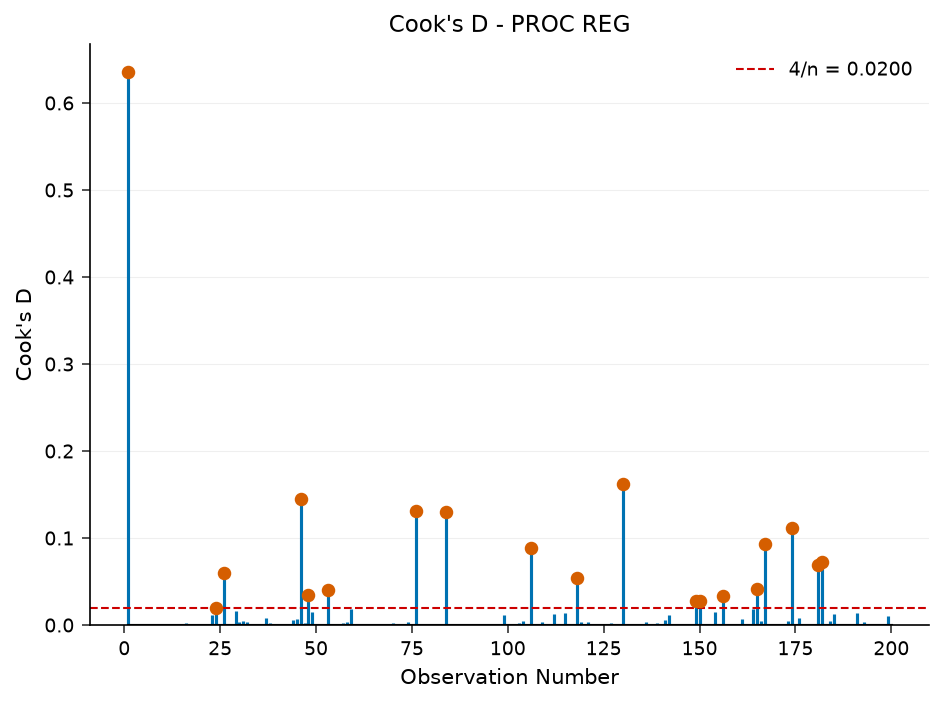

In [5]:
/* --------------------------------------------------------
   Regression: Budget efficiency and conversion drivers
   -------------------------------------------------------- */
proc reg data=campaigns;
    model revenue = budget impressions clicks conversions;
run;


/* force the kernel to flush wrapper-proc output into this cell */
data _reg_done; synced = 1; run;


In [6]:
/* --------------------------------------------------------
   Summary report: Top campaigns by ROAS
   -------------------------------------------------------- */
proc report data=campaigns;
    column channel creative_type budget revenue roas cpa;
    define channel / group;
    define creative_type / group;
    define budget / analysis mean format=dollar10.2;
    define revenue / analysis mean format=dollar10.2;
    define roas / analysis mean format=8.2;
    define cpa / analysis mean format=dollar10.2;
run;


channel   creative_type  budget    revenue   roas      cpa     
email     video          $3,653.07  $38,752.75  11.22     $3.73   
search    carousel       $6,617.58  $21,586.27  2.79      $64.30  
display   text           $3,332.86  $9,319.61  2.75      $18.96  
social    text           $5,476.82  $16,270.24  2.69      $18.36  
display   static         $4,003.00  $8,451.26  2.80      $18.80  
email     carousel       $5,091.17  $37,105.37  8.06      $6.08   
social    static         $6,966.67  $24,834.61  3.05      $18.18  
video     carousel       $4,830.71  $15,323.31  3.46      $16.24  
email     static         $2,751.40  $23,583.35  7.93      $7.10   
social    video          $4,115.33  $25,561.18  5.75      $8.91   
social    carousel       $4,199.00  $10,578.69  2.49      $20.88  
search    video          $7,247.75  $35,849.85  5.43      $7.87   
search    static         $5,542.80  $13,411.61  2.89      $19.34  
video     text           $4,888.50  $17,907.27  3.43      $16.46  


NOTE: PROC REPORT data=campaigns

NOTE: PROC REPORT output 20 observations with 6 variables.

NOTE: Read 200 rows from campaigns.
NOTE: Wrote (console) (20 rows, 6 columns).
NOTE: PROC REPORT elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

## 5. Results

Reading the executed output above, four findings hold up:

- **Channel is the dominant lever.** In the GLM, channel is the strongest term (F = 9.32, p < .0001), and creative type is also significant (F = 2.77, p = 0.0433); campaign week (p = 0.9172) and the channel-by-creative interaction (p = 1.0000) are not. The model accounts for 47.1% of ROAS variance (R-square = 0.471). The PROC MEANS table makes the channel gap concrete: email averages a ROAS of 9.21 against 3.43 (display), 3.33 (search), 3.65 (social), and 3.88 (video).

- **Email is efficient end to end.** Beyond ROAS, email shows the highest mean CTR (0.0372 vs 0.020-0.024 elsewhere) and the lowest mean CPA ($5.39 vs $15-29 for the other channels) - it converts cheaply, not just at high volume. (Search's mean CPA of $28.80 is inflated by a single high-CPA outlier - its std of 86.97 dwarfs the others - so its median CPA of $14.48 is the fairer read.)

- **Video is the best creative format.** Across creative types, video leads on both mean ROAS (7.28) and mean CTR (0.0328), ahead of carousel (4.56 / 0.0243), text (3.55 / 0.0219), and static (3.39 / 0.0206).

- **Revenue tracks conversions, not spend.** The PROC REG model of revenue (R-square = 0.864) finds only the conversions coefficient significant (estimate 35.56, p < .0001). Budget (p = 0.998), impressions (p = 0.245), and clicks (p = 0.810) add little once conversions are in the model - spending more does not buy revenue unless it buys conversions.

> **Recommendation:** Treat email and video as the high-efficiency core of the media mix and shift discretionary budget toward them. With 200 synthetic campaigns the channel and creative-type main effects are statistically established, while the channel-by-creative interaction is not - so the two levers can be optimised independently.

---

## 6. Export



In [7]:
/* --------------------------------------------------------
   Export campaign performance summary
   -------------------------------------------------------- */
data "campaign_performance.csv";
    set campaigns;
    keep campaign_id channel creative_type budget impressions
         clicks conversions revenue ctr roas cpa;
run;


NOTE: DATA campaign_performance.csv


NOTE: Read 200 rows from campaigns.
NOTE: Wrote campaign_performance.csv (200 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px; margin-bottom: 8px;">&copy; 2026 Jenner Analytics Ltd. All rights reserved. Jenner&trade; is a trademark of Jenner Analytics Ltd.</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 11px; line-height: 1.5;">This notebook is provided for demonstration purposes only. The analysis, data, and findings herein do not constitute marketing, business, or professional advice.</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px; margin-top: 8px;">Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a></div>
</div>